# CNN Components

## Start with the problem the components solve

Imagine recognizing a mark on a product even when it moves within the camera frame. We need local pattern detectors, a way to combine their responses, and a final decision. A convolutional neural network (CNN) is an artificial neural network that organizes these jobs around an image grid.

A component has a specific purpose: convolution learns local patterns; an activation lets the model combine evidence nonlinearly; downsampling reduces spatial size; normalization changes the scale of intermediate values; dropout adds training-time noise; and the output head turns features into task predictions. None of these operations alone guarantees a useful model. Learning and evaluation determine whether the chosen combination solves the task.

This lesson inspects each operation and follows a complete tiny CNN calculation. All weights in the arithmetic examples are deliberately chosen. The final update teaches one artificial example, not a trained image-recognition system.

Read the [code companion](15_CNN_Components.ipynb) to run the calculations and inspect the saved figures. The earlier [CNN lesson](14_Convolutional_Neural_Networks_Notes.ipynb) introduces the image-classification setting.

## See the complete worked pipeline

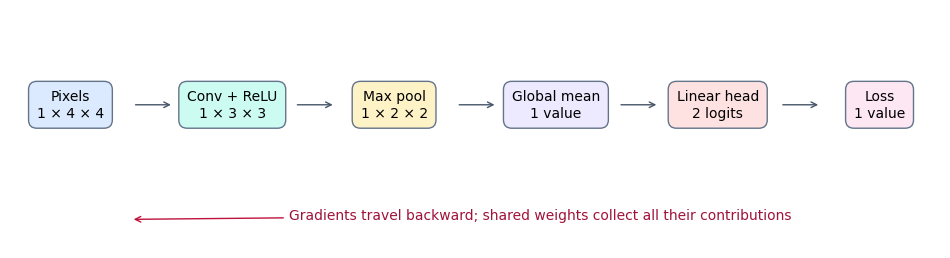

Shapes omit the batch dimension. The convolution and head contain nine parameters in total; ReLU, pooling, and averaging contain none. The loss compares the two logits to a known class label.

## Convolution: reuse one calculation across the image

An input tensor has shape `(N, C, H, W)`: examples, channels, height, width. In this example there is one image and one channel:

$$X=\begin{bmatrix}1&2&3&4\\5&6&7&8\\9&10&11&12\\13&14&15&16\end{bmatrix},\qquad K=\begin{bmatrix}1&0\\0&0\end{bmatrix}.$$

At the upper-left patch the filter computes $1(1)+2(0)+5(0)+6(0)=1$. One position to the right gives $2(1)+3(0)+6(0)+7(0)=2$. Each patch's upper-left number is selected, so the complete feature map with stride one, zero bias, and no padding is

$$Y=\begin{bmatrix}1&2&3\\5&6&7\\9&10&11\end{bmatrix}.$$

This unusually simple filter makes the later calculations transparent. Real filters learn combinations such as contrasts or textures. Each weight is shared across all nine patches rather than stored separately for each location. Deep-learning convolution normally uses cross-correlation: the kernel is not flipped.

A standard convolution learns $C_{out}(C_{in}K_hK_w+1)$ parameters with bias. This one learns four weights plus one bias, even though it produces nine output values. `F.conv2d` applies supplied tensors; `nn.Conv2d` stores the trainable parameters.

## Inspect the input, filter, and resulting map

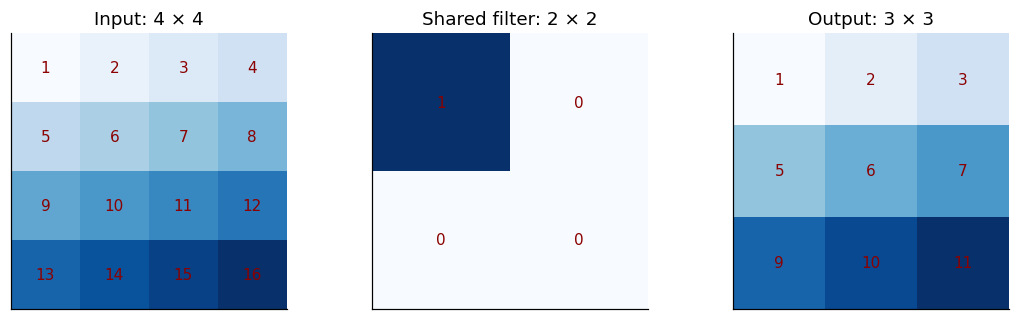

The filter selects the upper-left value in each patch. This transparent starting point lets us trace pooling and learning without hiding any arithmetic.

## Channels: combine measurements, not separate pictures

An RGB pixel has three input measurements. Each ordinary output filter spans all input channels and adds their contributions. An output channel is one detector's feature map; it is not necessarily a color channel.

For a complete small calculation, use two input channels at one position: $[2,5]$. A 1 × 1 filter with weights $[3,-1]$ and bias $0.5$ gives $2(3)+5(-1)+0.5=1.5$. A second filter with weights $[0,2]$ and bias $-1$ gives $2(0)+5(2)-1=9$. Two input channels became two different learned combinations, $[1.5,9]$.

The layer has $2(2\times1\times1+1)=6$ parameters. A 1 × 1 filter mixes channels but does not see neighboring pixels. A 3 × 3 filter mixes both channel and spatial information. More output filters can represent more patterns, at the cost of more parameters, computation, and activation memory.

## Padding, stride, and dilation: decide which pixels meet

**Padding** adds border values, often zeros. It allows a filter to reach boundary pixels in more positions and can preserve spatial dimensions. With a 3 × 3 all-ones kernel and padding one, the top-left patch of our 4 × 4 image is $[[0,0,0],[0,1,2],[0,5,6]]$. Its sum is $14$. Padding makes the output 4 × 4 instead of 2 × 2, but its border is an assumption, not observed image content.

**Stride** is the step between patch origins. A 2 × 2 all-ones kernel at stride two uses four non-overlapping patches. Their sums are $1+2+5+6=14$, $3+4+7+8=22$, $9+10+13+14=46$, and $11+12+15+16=54$, giving $[[14,22],[46,54]]$. Fewer locations reduce work and spatial detail; small shifts can change which samples are grouped.

**Dilation** spaces out the samples inside a filter. A 2 × 2 all-ones kernel with dilation two samples $[[1,3],[9,11]]$ at the top left, giving $24$. It covers a 3 × 3 extent using four weights. Larger reach is useful for context, but gaps can miss fine patterns.

For either spatial dimension, the output size is

$$H_{out}=\left\lfloor\frac{H+2P-D(K-1)-1}{S}\right\rfloor+1.$$

$H$ is input size, $P$ padding per side, $D$ dilation, $K$ filter size, and $S$ stride. The effective filter size is $D(K-1)+1$. For $H=4,K=2,D=2,P=0,S=1$, this gives $\lfloor(4-2-1)/1\rfloor+1=2$. Height and width follow the same logic.

## ReLU: allow a nonlinear decision

Convolution computes an affine function of its input. Stacking affine layers without nonlinear operations still produces one affine function. ReLU, $\max(0,z)$, changes that: it can keep a detector's positive evidence while suppressing its negative response.

For scores $[-2,0,3]$, outputs are $[0,0,3]$. During backpropagation, an upstream gradient of one becomes zero at the negative score, zero at exactly zero under PyTorch's convention, and one at the positive score. This gives a simple learning path on the positive side but can leave some paths inactive.

ReLU has no learned parameters. It does not identify a “good” pixel; the usefulness of a positive response depends on the learned filter. Our hand-set feature map contains only positive values, so ReLU leaves it unchanged. The separate signed example shows why that is not always true.

## Pooling: summarize a local region and route its gradient

Max pooling asks whether there is a strong response anywhere in a window. Average pooling measures the mean response. Neither learns filter weights. They discard detail, which can help a location-tolerant classifier but hurt precise localization.

For $[[1,3],[2,0]]$, max pooling returns $3$ while average pooling returns $(1+3+2+0)/4=1.5$. If the loss derivative with respect to the pooled result is one, max pooling sends that derivative only to the unique maximum: $[[0,1],[0,0]]$. Average pooling distributes it equally: $[[0.25,0.25],[0.25,0.25]]$. Tied maxima do not distribute the derivative equally by default; the selected index receives it.

For our 3 × 3 feature map, a 2 × 2 max pool with stride one produces:

- Top left: $\max(1,2,5,6)=6$.
- Top right: $\max(2,3,6,7)=7$.
- Bottom left: $\max(5,6,9,10)=10$.
- Bottom right: $\max(6,7,10,11)=11$.

Thus pooled values are $[[6,7],[10,11]]$. These windows overlap. The default stride of `MaxPool2d(2)` is two; we explicitly request one for this worked example.

## Batch normalization: give each channel a controlled scale

A channel's values can change scale during training. Batch normalization standardizes them using training-batch statistics, then applies a learned scale $\gamma$ and shift $\beta$. This can make optimization easier, but it is not required for every CNN and does not guarantee improved generalization.

`BatchNorm2d` calculates a mean and variance per channel across the batch and spatial positions. For one channel containing values $[1,3]$, mean $\mu=(1+3)/2=2$ and the training-forward variance is $((1-2)^2+(3-2)^2)/2=1$. With $\epsilon=10^{-5}$, $\gamma=2$, and $\beta=0.5$:

$$y=2\frac{x-2}{\sqrt{1+10^{-5}}}+0.5\approx[-1.49999,2.49999].$$

The small epsilon prevents division by zero. The learned scale and shift allow the network to choose an appropriate distribution rather than permanently forcing mean zero and variance one.

**Training and inference differ.** During training, PyTorch also updates running statistics. Its running variance uses the unbiased estimate: with these two values that is $(1+1)/(2-1)=2$. We set momentum to one in the demonstration so running statistics become exactly this batch's values. In evaluation mode, the outputs therefore use variance two and become approximately $[-0.914210,1.914210]$. In normal training the running estimates usually blend many batches. BatchNorm momentum controls that blend; it is not optimizer momentum.

Because statistics combine training examples, training-mode BatchNorm can make one example's output depend on other examples in its batch. A preceding convolution's bias is often omitted when immediately followed by BatchNorm with learned shift, which already provides a per-channel offset.

## Dropout: avoid depending on one exact set of features

Dropout randomly removes activations during training. It encourages learning under missing evidence and can reduce overfitting, although too much dropout can prevent useful fitting. It is a training choice to validate, not a compulsory CNN component.

Ordinary dropout masks individual values. `Dropout2d` masks entire channels separately for each image. At probability $p=0.5$, a kept value is scaled by $1/(1-p)=2$. An illustrative channel vector $[1,2,3,4]$ with keep mask $[1,0,1,0]$ becomes $[2,0,6,0]$. The expected multiplier is $0.5(0)+0.5(2)=1$, preserving the expected activation at this operation. This does not guarantee that the entire nonlinear network's expected prediction stays unchanged.

In evaluation mode, dropout returns the original values. No further scaling is needed because the scaling happened during training. The companion prints a seeded random mask, which need not equal the illustrative mask above. Forgetting `eval()` leaves prediction noisy. Dropout has no learned parameters.

## Flatten or globally average: choose what reaches the head

Flattening changes shape, not values: $[[6,7],[10,11]]$ becomes $[6,7,10,11]$. A dense head can give each location its own weight, but its parameter count grows with spatial size and it depends on a fixed feature-grid shape.

Global average pooling instead summarizes each channel. Our one channel becomes $s=(6+7+10+11)/4=8.5$. It preserves the channel's identity while discarding explicit location. A two-class dense head on the flattened four values has $2(4+1)=10$ parameters. A head on the one channel mean has $2(1+1)=4$. A smaller head may be useful, but averaging can erase a distinction that depends on where evidence occurs.

For a complete class calculation, set head weights to $[0.1,-0.1]$ and both biases to zero. The logits are $[0.1(8.5),-0.1(8.5)]=[0.85,-0.85]$. Softmax probabilities are approximately $[0.845535,0.154465]$. If the artificial target is class one, cross-entropy is $-\ln(0.154465)\approx1.867786$.

The argmax prediction is class zero and is wrong for this target. A probability transformation lets us interpret confidence; the loss uses raw logits directly for numerical stability. The artificial class IDs here carry no claimed real-world meaning.

## Follow the error through every learned parameter

Now connect convolution → ReLU → overlapping max pooling → global averaging → the two-class head. BatchNorm and dropout remain separate demonstrations so every number in this complete update is deterministic and easy to follow.

For one-example softmax cross-entropy, logit derivatives are probabilities minus the one-hot target. Set $q=0.845534735$; the two derivatives are $[q,-q]$.

**Head weights and biases:** each weight multiplies $s=8.5$, giving weight gradients $[8.5q,-8.5q]\approx[7.187045,-7.187045]$. Each bias adds directly, giving bias gradients $[q,-q]$. The derivative reaching $s$ is $q(0.1)+(-q)(-0.1)=0.2q\approx0.169107$.

**Averaging and max pooling:** the mean sends one quarter of that derivative to each pooled value. Pooling routes those four signals to feature values 6, 7, 10, and 11. ReLU passes them because those scores are positive. No gradient flows through the other feature-map locations for this example.

**All four convolution weights:** the selected patches' top-left pixels are $[6,7,10,11]$, top-right pixels $[7,8,11,12]$, bottom-left pixels $[10,11,14,15]$, and bottom-right pixels $[11,12,15,16]$. Their means are $[8.5,9.5,12.5,13.5]$. Each shared weight's gradient is its mean input contribution times $0.2q$:

$$\nabla_K L\approx\begin{bmatrix}1.437409&1.606516\\2.113837&2.282944\end{bmatrix}.$$

The convolution bias affects all four selected responses equally, so its gradient is $0.2q\approx0.169107$. This accounts for every learned value: four filter weights, one convolution bias, two head weights, and two head biases—nine parameters.

**Update them together using the old state's gradients.** Plain SGD with rate $0.001$ gives

$$K'\approx\begin{bmatrix}0.998563&-0.001607\\-0.002114&-0.002283\end{bmatrix},\quad b'\approx-0.000169,$$

head weights approximately $[0.092813,-0.092813]$ and head biases $[-0.000846,0.000846]$.

The pooling winners remain the same. Recompute the global mean as

$$s'=8.5K'_{00}+9.5K'_{01}+12.5K'_{10}+13.5K'_{11}+b'\approx8.415108.$$

The new logits are approximately $[0.780186,-0.780186]$ and loss is $1.751039$, below $1.867786$. The decision is still wrong, but probability on the correct class has increased. This is one measured improvement on one example, not evidence of generalization. Rounded values are for reading; the code uses full precision.

## Assemble a larger block without hiding its shape or cost

A plausible RGB classifier could use Conv → BatchNorm → ReLU → MaxPool, then another Conv → BatchNorm → ReLU, channel dropout, global averaging, and a linear head. This is a demonstration of assembly, not a recommended optimum or a trained model.

For four 16 × 16 RGB images, shapes are `(4,3,16,16)` → `(4,8,16,16)` → `(4,8,8,8)` → `(4,16,8,8)` → `(4,16,1,1)` → `(4,16)` → `(4,2)`. Normalization, activations, and dropout keep the shape of their input.

With no convolution biases before BatchNorm, parameter counts are $8(3\times3\times3)=216$, $2(8)=16$ for the first normalization, $16(8\times3\times3)=1152$, $2(16)=32$ for the second normalization, and $2(16+1)=34$ for the head. Total: $216+16+1152+32+34=1450$. Running means and variances are stored buffers, not gradient-trained parameters.

Convolution and pooling also widen the **receptive field**, the region of input that can affect an output. Start with field size one and sampling jump one. A 3 × 3 stride-one convolution gives field three. A 2 × 2 stride-two pool gives field four and jump two. Another 3 × 3 convolution adds $(3-1)\times2=4$, giving field eight. This is the interior local path: training-mode BatchNorm additionally couples values through batch statistics, and global averaging combines all spatial locations.

## Choose components according to the information the task needs

Use shared local filters when the same local pattern can matter at several positions. Use more output channels when multiple detectors are useful. Preserve more spatial resolution when exact location matters. Pooling and global averaging may suit an image-level label but can erase information needed for detection or segmentation.

Normalization and dropout address training behavior, not missing labels or an unsuitable task definition. Their settings need validation. Always distinguish `eval()`, which changes the behavior of certain layers, from `torch.no_grad()`, which turns off gradient recording for its context. Neither function trains a model.

The completed calculation shows how a class error reaches every parameter through the chosen components. The remaining practical step is training on representative examples and evaluating on separate data. A correct hand calculation and a falling single-example loss verify a mechanism; they do not establish accuracy on unseen images.